# 01 — CST 拟合验证 (Phase 0)

对 NACA 0012 / 2412 做 CST 拟合, 可视化重建精度与钝后缘效果。
验收: 每个翼面 MSE < 1e-5。

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
from geometry.naca import naca4
from geometry.cst_params import fit_cst, cst_surface, generate_airfoil

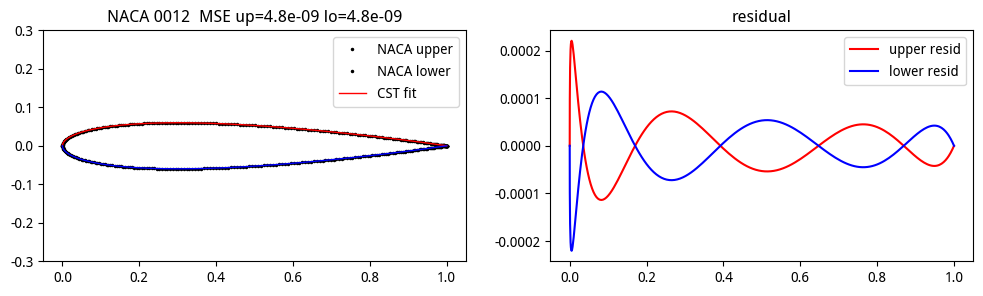

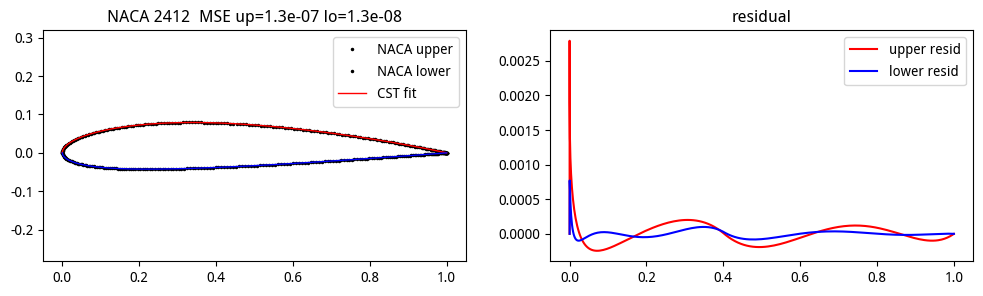

In [2]:
for code in ['0012', '2412']:
    xu, yu, xl, yl = naca4(code, n_pts=201)
    A_up, mse_up = fit_cst(xu, yu, n_coef=5, yte=0.0)
    A_lo, mse_lo = fit_cst(xl, yl, n_coef=5, yte=0.0)
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    ax[0].plot(xu, yu, 'k.', ms=3, label='NACA upper')
    ax[0].plot(xl, yl, 'k.', ms=3, label='NACA lower')
    ax[0].plot(xu, cst_surface(A_up, xu, yte=0.0), 'r-', lw=1, label='CST fit')
    ax[0].plot(xl, cst_surface(A_lo, xl, yte=0.0), 'b-', lw=1)
    ax[0].axis('equal'); ax[0].legend()
    ax[0].set_title(f'NACA {code}  MSE up={mse_up:.1e} lo={mse_lo:.1e}')
    ax[1].plot(xu, yu - cst_surface(A_up, xu, yte=0.0), 'r-', label='upper resid')
    ax[1].plot(xl, yl - cst_surface(A_lo, xl, yte=0.0), 'b-', label='lower resid')
    ax[1].set_title('residual'); ax[1].legend()
    plt.show()

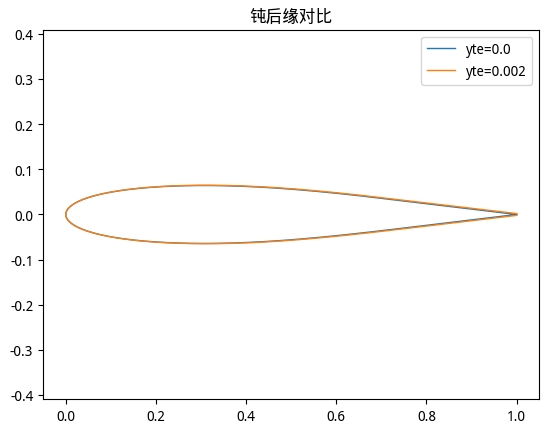

In [3]:
# 钝后缘 (yte=+-0.002) 对比尖后缘
A_up = np.array([0.18, 0.16, 0.18, 0.13, 0.12]); A_lo = -A_up
for yte in [0.0, 0.002]:
    c = generate_airfoil(A_up, A_lo, yte_upper=yte, yte_lower=-yte)
    plt.plot(c[:, 0], c[:, 1], lw=1, label=f'yte={yte}')
plt.axis('equal'); plt.legend(); plt.title('钝后缘对比'); plt.show()

In [4]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontManager

fm = FontManager()
# 过滤出系统里常见的中文字体
zh_fonts = [f.name for f in fm.ttflist if 'sans' in f.name.lower() or 'heiti' in f.name.lower() or 'song' in f.name.lower()]
print(set(zh_fonts))

{'Ubuntu Sans Mono', 'DejaVu Sans', 'DejaVu Sans Mono', 'Ubuntu Sans', 'DejaVu Sans Display'}


In [5]:
import matplotlib
print(matplotlib.matplotlib_fname())

/home/kunix/miniconda3/envs/data/lib/python3.12/site-packages/matplotlib/mpl-data/matplotlibrc


In [6]:
from matplotlib.font_manager import FontManager
fm = FontManager()

# 检查系统里的宋体、黑体以及 Times New Roman
academic_fonts = [f.name for f in fm.ttflist if 'sim' in f.name.lower() or 'times' in f.name.lower()]
print(set(academic_fonts))

set()
